# data analytics - final exam

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("Bank_Customer_Churn_Prediction_FinalCleaned.csv")

In [4]:
df.shape

(9996, 12)

In [5]:
df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1.0
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0.0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1.0
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0.0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0.0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9996 entries, 0 to 9995
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       9996 non-null   int64  
 1   credit_score      9996 non-null   int64  
 2   country           9996 non-null   object 
 3   gender            9996 non-null   object 
 4   age               9996 non-null   int64  
 5   tenure            9996 non-null   int64  
 6   balance           9996 non-null   float64
 7   products_number   9996 non-null   int64  
 8   credit_card       9996 non-null   int64  
 9   active_member     9996 non-null   int64  
 10  estimated_salary  9996 non-null   float64
 11  churn             9996 non-null   float64
dtypes: float64(3), int64(7), object(2)
memory usage: 937.3+ KB


In [7]:
# screening hubungan setiap variabel kategorikal dengan churn
# menghitung churn rate (%) pada setiap kategori
import pandas as pd

categorical_features = [
    'country',
    'gender',
    'tenure',
    'products_number',
    'credit_card',
    'active_member'
]

for feature in categorical_features:

    print("="*60)
    print(f"{feature.upper()}")

    summary = (
        df.groupby(feature)['churn']
          .agg(['count','mean'])
          .reset_index()
    )

    summary['Churn Rate (%)'] = summary['mean']*100

    print(summary[[feature,'count','Churn Rate (%)']])

COUNTRY
   country  count  Churn Rate (%)
0   France   5012       16.161213
1  Germany   2508       32.456140
2    Spain   2476       16.680129
GENDER
   gender  count  Churn Rate (%)
0  Female   4542       25.077059
1    Male   5454       16.464980
TENURE
    tenure  count  Churn Rate (%)
0        0    413       23.002421
1        1   1035       22.415459
2        2   1047       19.197708
3        3   1009       21.110010
4        4    989       20.525784
5        5   1012       20.652174
6        6    967       20.268873
7        7   1026       17.251462
8        8   1024       19.238281
9        9    984       21.646341
10      10    490       20.612245
PRODUCTS_NUMBER
   products_number  count  Churn Rate (%)
0                1   5083       27.719850
1                2   4587        7.586658
2                3    266       82.706767
3                4     60      100.000000
CREDIT_CARD
   credit_card  count  Churn Rate (%)
0            0   2944       20.822011
1            1   7052

In [8]:
# distribusi jumlah pelanggan pada setiap jumlah produk
product_count = (
    df['products_number']
      .value_counts()
      .sort_index()
      .reset_index()
)

product_count.columns = ['Number of Products', 'Total Customers']

print(product_count)

   Number of Products  Total Customers
0                   1             5083
1                   2             4587
2                   3              266
3                   4               60


## 2A

### 1) Relationship Analysis:Pengaruh Jumlah Produk terhadap Tingkat Churn

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# menghitung jumlah pelanggan dan churn rate berdasarkan jumlah produk
product_analysis = (
    df.groupby('products_number')['churn']
      .agg(['count', 'mean'])
      .reset_index()
)

product_analysis['Churn Rate (%)'] = (
    product_analysis['mean'] * 100
)

print(product_analysis)

   products_number  count      mean  Churn Rate (%)
0                1   5083  0.277199       27.719850
1                2   4587  0.075867        7.586658
2                3    266  0.827068       82.706767
3                4     60  1.000000      100.000000


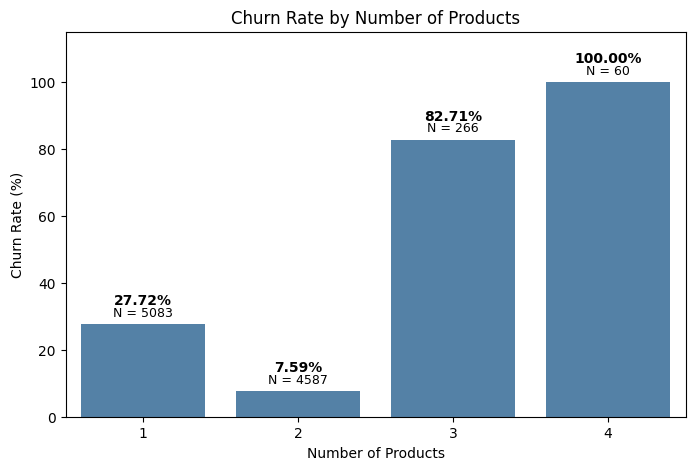

In [10]:
# visualisasi
plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=product_analysis,
    x='products_number',
    y='Churn Rate (%)',
    color='steelblue'
)

# menambahkan persentase churn dan jumlah pelanggan di atas setiap bar
for i, row in product_analysis.iterrows():

    # persentase churn
    ax.text(
        i,
        row['Churn Rate (%)'] + 5,
        f"{row['Churn Rate (%)']:.2f}%",
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

    # jumlah pelanggan (sample size)
    ax.text(
        i,
        row['Churn Rate (%)'] + 1.5,
        f"N = {int(row['count'])}",
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.title("Churn Rate by Number of Products")
plt.xlabel("Number of Products")
plt.ylabel("Churn Rate (%)")

plt.ylim(0,115)

plt.show()

### 2) Subgroup Comparison: Churn Rate berdasarkan Jumlah Produk dan Status Keaktifan

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# menghitung churn rate berdasarkan jumlah produk dan status keaktifan pelanggan
product_active = (
    df.groupby(['products_number', 'active_member'])['churn']
      .agg(['count', 'mean'])
      .reset_index()
)

product_active['Churn Rate (%)'] = product_active['mean'] * 100

print(product_active)

# mengubah label active_member biar lebih gampang dibaca
product_active['Member Status'] = product_active['active_member'].map({
    0: 'Inactive',
    1: 'Active'
})

   products_number  active_member  count      mean  Churn Rate (%)
0                1              0   2521  0.366521       36.652122
1                1              1   2562  0.189305       18.930523
2                2              0   2144  0.098881        9.888060
3                2              1   2443  0.055669        5.566926
4                3              0    153  0.882353       88.235294
5                3              1    113  0.752212       75.221239
6                4              0     31  1.000000      100.000000
7                4              1     29  1.000000      100.000000


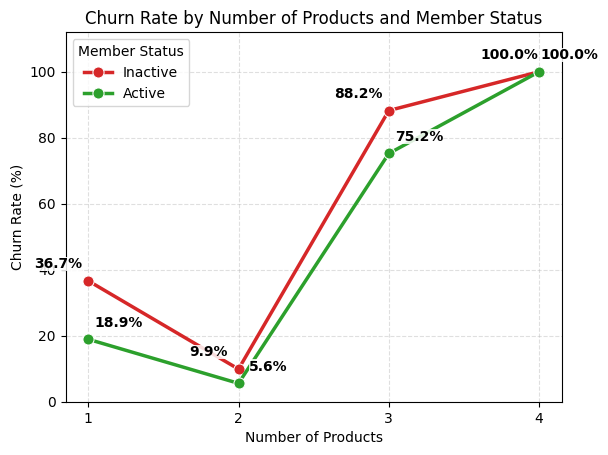

In [12]:
# visualisasi
ax = sns.lineplot(
    data=product_active,
    x='products_number',
    y='Churn Rate (%)',
    hue='Member Status',
    palette={
        'Inactive': '#d62728',   # Merah
        'Active': '#2ca02c'      # Hijau
    },
    marker='o',
    linewidth=2.5,
    markersize=8
)

# label persentase
for _, row in product_active.iterrows():

    # geser sedikit ke kiri/kanan biar label kedua garis ganumpuk
    x_offset = -0.20 if row['Member Status'] == 'Inactive' else 0.20

    plt.text(
        row['products_number'] + x_offset,
        row['Churn Rate (%)'] + 3,
        f"{row['Churn Rate (%)']:.1f}%",
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold',
        bbox=dict(
            facecolor='white',
            edgecolor='none',
            alpha=0.85,
            pad=0.2
        )
    )

plt.title('Churn Rate by Number of Products and Member Status')
plt.xlabel('Number of Products')
plt.ylabel('Churn Rate (%)')

plt.xticks([1,2,3,4])
plt.ylim(0,112)

plt.grid(True, linestyle='--', alpha=0.4)

plt.legend(title='Member Status')

plt.show()

### Subgroup Comparison: Pengaruh Saldo dan Status Keaktifan terhadap Churn Nasabah

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# buat kategori saldo
def balance_group(balance):
    if balance == 0:
        return 'Zero Balance'
    elif balance <= 100000:
        return 'Low Balance'
    elif balance <= 150000:
        return 'Medium Balance'
    else:
        return 'High Balance'

df['Balance_Group'] = df['balance'].apply(balance_group)

#hitung churn rate
balance_active = (
    df.groupby(['Balance_Group', 'active_member'])['churn']
      .agg(['count', 'mean'])
      .reset_index()
)

balance_active['Churn Rate (%)'] = balance_active['mean'] * 100

balance_active['Member Status'] = balance_active['active_member'].map({
    0: 'Inactive',
    1: 'Active'
})

# mengatur urutan kategori
balance_order = [
    'Zero Balance',
    'Low Balance',
    'Medium Balance',
    'High Balance'
]

balance_active['Balance_Group'] = pd.Categorical(
    balance_active['Balance_Group'],
    categories=balance_order,
    ordered=True
)

balance_active = balance_active.sort_values('Balance_Group')

print(balance_active)

    Balance_Group  active_member  count      mean  Churn Rate (%)  \
6    Zero Balance              0   1744  0.183486       18.348624   
7    Zero Balance              1   1870  0.096257        9.625668   
2     Low Balance              0    749  0.280374       28.037383   
3     Low Balance              1    835  0.138922       13.892216   
4  Medium Balance              0   1872  0.334936       33.493590   
5  Medium Balance              1   1957  0.183955       18.395503   
0    High Balance              0    484  0.299587       29.958678   
1    High Balance              1    485  0.162887       16.288660   

  Member Status  
6      Inactive  
7        Active  
2      Inactive  
3        Active  
4      Inactive  
5        Active  
0      Inactive  
1        Active  


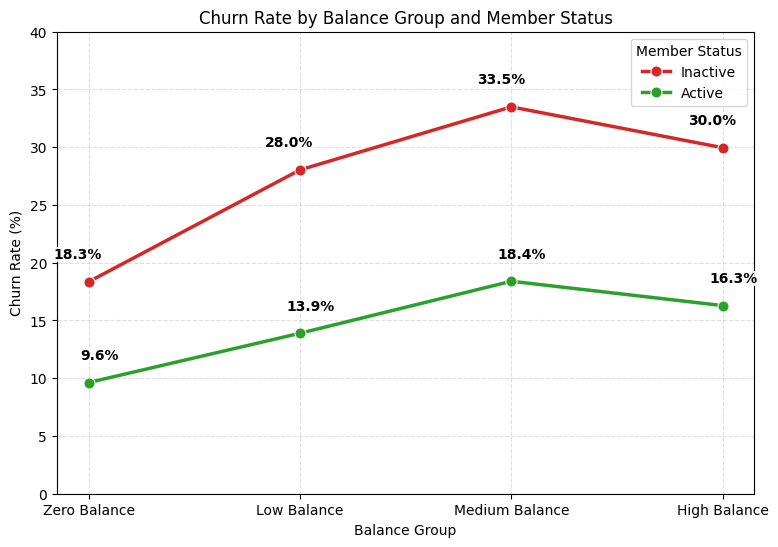

In [14]:
# visualisasi
plt.figure(figsize=(9,6))

ax = sns.lineplot(
    data=balance_active,
    x='Balance_Group',
    y='Churn Rate (%)',
    hue='Member Status',
    palette={
        'Inactive': '#d62728',
        'Active': '#2ca02c'
    },
    marker='o',
    linewidth=2.5,
    markersize=8
)

# label persentase
for _, row in balance_active.iterrows():

    x = balance_order.index(row['Balance_Group'])

    x_offset = -0.05 if row['Member Status'] == 'Inactive' else 0.05

    plt.text(
        x + x_offset,
        row['Churn Rate (%)'] + 2,
        f"{row['Churn Rate (%)']:.1f}%",
        ha='center',
        fontsize=10,
        fontweight='bold',
        bbox=dict(
            facecolor='white',
            edgecolor='none',
            alpha=0.85,
            pad=0.2
        )
    )

plt.title("Churn Rate by Balance Group and Member Status")
plt.xlabel("Balance Group")
plt.ylabel("Churn Rate (%)")

plt.ylim(0,40)

plt.grid(True, linestyle='--', alpha=0.4)

plt.legend(title='Member Status')

plt.show()

### Subgroup Comparison: Pengaruh Status Keaktifan pada Setiap Negara terhadap Churn Nasabah

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# menghitung churn rate berdasarkan negara dan status keaktifan pelanggan
country_active = (
    df.groupby(['country', 'active_member'])['churn']
      .agg(['count', 'mean'])
      .reset_index()
)

country_active['Churn Rate (%)'] = country_active['mean'] * 100

print(country_active)

# label status member
country_active['Member Status'] = country_active['active_member'].map({
    0: 'Inactive',
    1: 'Active'
})

# mengatur urutan negara
country_order = ['France', 'Germany', 'Spain']

country_active['country'] = pd.Categorical(
    country_active['country'],
    categories=country_order,
    ordered=True
)

country_active = country_active.sort_values('country')

   country  active_member  count      mean  Churn Rate (%)
0   France              0   2423  0.211308       21.130830
1   France              1   2589  0.115102       11.510236
2  Germany              0   1261  0.410785       41.078509
3  Germany              1   1247  0.237370       23.736969
4    Spain              0   1165  0.233476       23.347639
5    Spain              1   1311  0.107551       10.755149


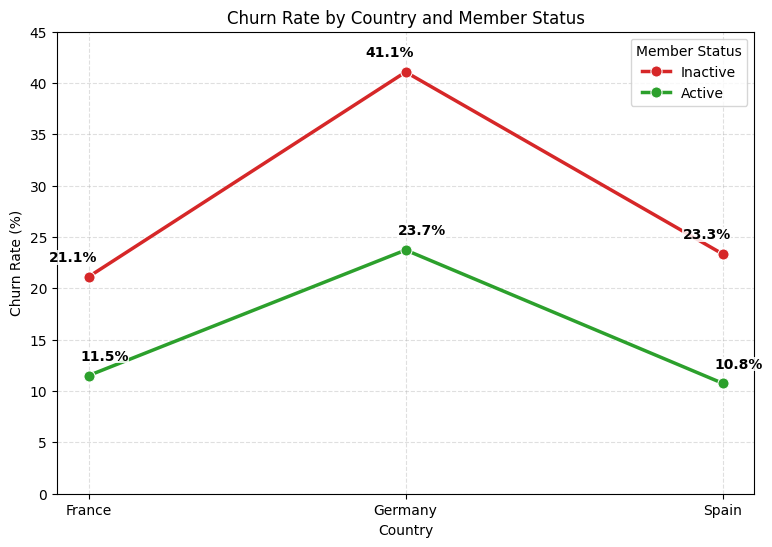

In [16]:
# ==========================================================
# Visualisasi
# ==========================================================

plt.figure(figsize=(9,6))

ax = sns.lineplot(
    data=country_active,
    x='country',
    y='Churn Rate (%)',
    hue='Member Status',
    palette={
        'Inactive': '#d62728',
        'Active': '#2ca02c'
    },
    marker='o',
    linewidth=2.5,
    markersize=8
)

# ==========================================================
# Menambahkan label persentase
# ==========================================================

for _, row in country_active.iterrows():

    x = country_order.index(row['country'])
    x_offset = -0.05 if row['Member Status'] == 'Inactive' else 0.05

    plt.text(
        x + x_offset,
        row['Churn Rate (%)'] + 1.5,
        f"{row['Churn Rate (%)']:.1f}%",
        ha='center',
        fontsize=10,
        fontweight='bold',
        bbox=dict(
            facecolor='white',
            edgecolor='none',
            alpha=0.85,
            pad=0.2
        )
    )

plt.title("Churn Rate by Country and Member Status")
plt.xlabel("Country")
plt.ylabel("Churn Rate (%)")

plt.ylim(0, 45)

plt.grid(True, linestyle='--', alpha=0.4)

plt.legend(title='Member Status')

plt.show()

### Eksplorasi Hipotesis Tambahan

/tmp/ipykernel_3677/585634669.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Age_Group')['products_number']
/tmp/ipykernel_3677/585634669.py:44: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Age_Group')['balance']


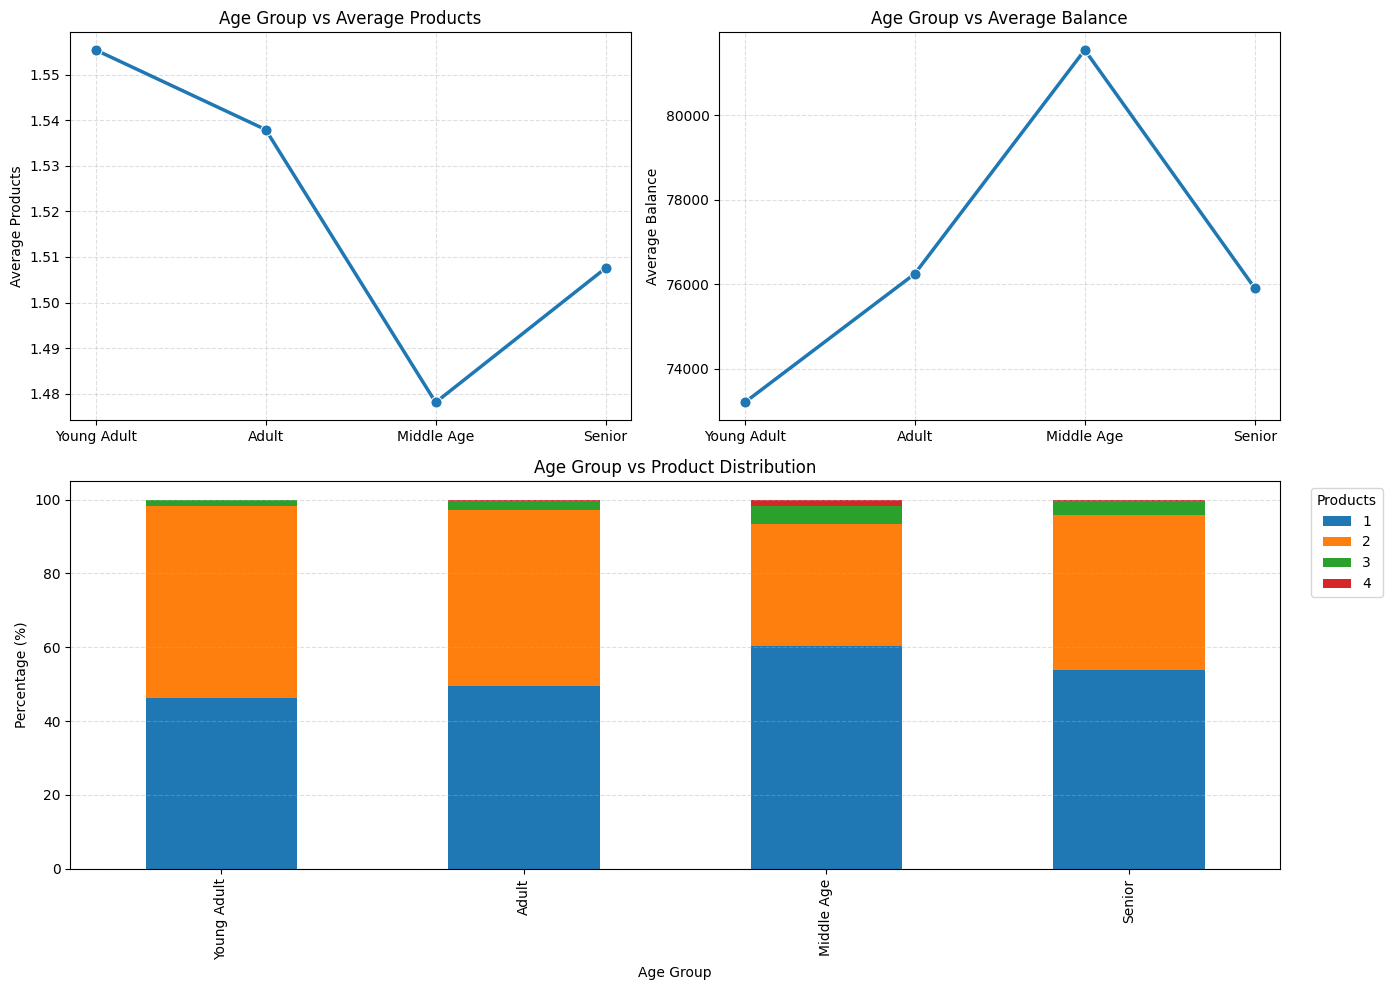

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# layout 2 atas, 1 bawah
fig = plt.figure(figsize=(14, 10))

# grafik 1: Age Group vs Average Products
ax1 = plt.subplot(2, 2, 1)

# Membuat kelompok usia
df['Age_Group'] = pd.cut(
    df['age'],
    bins=[18, 30, 45, 60, 100],
    labels=['Young Adult', 'Adult', 'Middle Age', 'Senior'],
    include_lowest=True
)

age_product = (
    df.groupby('Age_Group')['products_number']
      .mean()
      .reset_index()
)

sns.lineplot(
    data=age_product,
    x='Age_Group',
    y='products_number',
    marker='o',
    linewidth=2.5,
    markersize=8,
    ax=ax1
)

ax1.set_title('Age Group vs Average Products')
ax1.set_xlabel('')
ax1.set_ylabel('Average Products')
ax1.grid(True, linestyle='--', alpha=0.4)

# grafik 2: Age Group vs Average Balance
ax2 = plt.subplot(2, 2, 2)

age_balance = (
    df.groupby('Age_Group')['balance']
      .mean()
      .reset_index()
)

sns.lineplot(
    data=age_balance,
    x='Age_Group',
    y='balance',
    marker='o',
    linewidth=2.5,
    markersize=8,
    ax=ax2
)

ax2.set_title('Age Group vs Average Balance')
ax2.set_xlabel('')
ax2.set_ylabel('Average Balance')
ax2.grid(True, linestyle='--', alpha=0.4)

# grafik 3: Age Group vs Product Distributio
ax3 = plt.subplot(2, 1, 2)

age_distribution = (
    pd.crosstab(
        df['Age_Group'],
        df['products_number'],
        normalize='index'
    ) * 100
)

age_distribution.plot(
    kind='bar',
    stacked=True,
    ax=ax3
)

ax3.set_title('Age Group vs Product Distribution')
ax3.set_xlabel('Age Group')
ax3.set_ylabel('Percentage (%)')
ax3.grid(True, axis='y', linestyle='--', alpha=0.4)

ax3.legend(
    title='Products',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

#### Penyebab tingginya churn pada kelompok usia yang lebih tua belum dapat dijelaskan menggunakan variabel yang tersedia dalam dataset. Kemungkinan terdapat faktor lain di luar dataset, seperti kualitas layanan, preferensi penggunaan layanan digital, maupun kepuasan pelanggan.

## 3A & 3B

### Model 1: Logistic Regression
Model Logistic Regression digunakan sebagai **baseline model** untuk memprediksi kemungkinan pelanggan melakukan churn.

Logistic Regression dipilih karena sesuai untuk permasalahan klasifikasi biner, memiliki proses pelatihan yang relatif cepat, serta mampu memberikan interpretasi mengenai pengaruh masing-masing variabel terhadap peluang terjadinya churn melalui nilai koefisien model.

Model dibangun menggunakan data training dan dievaluasi menggunakan data testing untuk mengukur kemampuan model dalam melakukan prediksi terhadap data yang belum pernah dilihat sebelumnya (generalization).

Evaluasi performa model dilakukan menggunakan metrik berikut:

1. **F1-Score**: Mengukur keseimbangan antara precision dan recall sehingga lebih sesuai digunakan pada dataset yang memiliki distribusi kelas tidak seimbang (imbalanced dataset).
2. **ROC-AUC Score**: Mengukur kemampuan model dalam membedakan pelanggan yang churn dan tidak churn berdasarkan probabilitas prediksi yang dihasilkan.
3. **Confusion Matrix**: Menampilkan jumlah prediksi yang benar dan salah pada setiap kelas sehingga memudahkan interpretasi performa model.
4. **ROC Curve**: Memvisualisasikan kemampuan model dalam membedakan kedua kelas pada berbagai nilai threshold.

Selain itu, dilakukan **robustness check** dengan membandingkan performa model pada data training dan data testing untuk memastikan model mampu melakukan generalisasi dengan baik serta tidak mengalami overfitting.

Selanjutnya, performa Logistic Regression akan dibandingkan dengan Random Forest Classifier untuk menentukan model yang paling efektif dalam memprediksi customer churn.

#### 1. import library

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay

#### 2. load dataset

In [21]:
from google.colab import files
import os

dataset_path = '/content/Bank_Customer_Churn_Prediction_FinalCleaned.csv'

if not os.path.exists(dataset_path):
    print("Upload file dataset:")
    uploaded = files.upload()
else:
    print("Dataset sudah tersedia di direktori /content/.")

df = pd.read_csv(dataset_path)
df.head(10)

Dataset sudah tersedia di direktori /content/.


,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1.0
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0.0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1.0
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0.0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0.0
5,15574012,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1.0
6,15656148,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1.0
7,15792365,501,France,Male,44,4,142051.07,2,0,1,74940.50,0.0
8,15592389,684,France,Male,27,2,134603.88,1,1,1,71725.73,0.0
9,15767821,528,France,Male,31,6,102016.72,2,0,0,80181.12,0.0


#### 3. data preparation berdasarkan data uts

In [22]:
# feature selection
# memisahkan variabel prediktor (X) dan target (y) & ngapus kolom customer_id karena hanya berfungsi sebagai identitas pelanggan
X = df.drop(columns=['customer_id', 'churn'])
y = df['churn']

# menentukan jenis fitur
# fitur numerik akan distandardisasi, fitur kategorikal diubah menggunakan One-Hot Encoding
numerical_cols = [
    'age',
    'tenure',
    'balance',
    'products_number',
    'estimated_salary',
    'active_member',
]

categorical_cols = [
    'country',
    'gender'
]

# data preprocessing
# StandardScaler digunakan untuk menyamakan skala fitur numerik agar LR bekerja optimal
# OneHotEncoder digunakan untuk mengubah data kategorikal menjadi bentuk numerik
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first'), categorical_cols)
    ]
)

# train-test split
# dataset dibagi menjadi: 80% data training & 20% data testing
# stratify digunakan agar proporsi kelas churn & non-churn tetap seimbang pada kedua dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# transformasi data
# preprocessor dipelajari menggunakan data training kemudian diterapkan pada data testing untuk menghindari data leakage
X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)

# nampilin informasi hasil preprocessing
print("=== Data Preparation Summary ===")
print(f"Training data : {X_train.shape[0]:,} rows")
print(f"Testing data  : {X_test.shape[0]:,} rows")
print(f"Number of features before preprocessing : {X.shape[1]}")
print(f"Number of features after preprocessing  : {X_train_scaled.shape[1]}")

=== Data Preparation Summary ===
Training data : 7,996 rows
Testing data  : 2,000 rows
Number of features before preprocessing : 10
Number of features after preprocessing  : 9


#### 4. modelling

In [23]:
# nampilin informasi data training
print("=== Training Data Summary ===")
print(f"Training data : {X_train.shape[0]:,} rows")
print(f"Testing data  : {X_test.shape[0]:,} rows")
print(f"Churn ratio (training data): {y_train.mean():.2%}")

# model Logistic Regression
lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000,
    class_weight='balanced'
)

# training model menggunakan data training
lr_model.fit(X_train_scaled, y_train)

print("\nLogistic Regression model has been successfully trained.")

=== Training Data Summary ===
Training data : 7,996 rows
Testing data  : 2,000 rows
Churn ratio (training data): 20.37%

Logistic Regression model has been successfully trained.


#### 5. prediction

In [24]:
# pediksi kelas pada data testing
y_pred = lr_model.predict(X_test_scaled)

# prediksi probabilitas pelanggan melakukan churn, nilainya digunakan untuk ROC-AUC dan ROC Curve
y_prob = lr_model.predict_proba(X_test_scaled)[:, 1]

# nampilin contoh hasil prediksi (10 pelanggan pertama pada data testing)
prediction_sample = pd.DataFrame({
    'Actual': y_test.iloc[:10].values,
    'Predicted': y_pred[:10],
    'Churn Probability': y_prob[:10]
})

prediction_sample['Churn Probability'] = (
    prediction_sample['Churn Probability'] * 100
).round(2)

print("=== Prediction Sample ===")
print(prediction_sample)

=== Prediction Sample ===
   Actual  Predicted  Churn Probability
0     0.0        0.0              16.28
1     0.0        0.0              46.04
2     0.0        0.0              12.02
3     0.0        0.0              34.92
4     1.0        0.0              20.71
5     1.0        1.0              71.53
6     0.0        0.0              13.67
7     0.0        0.0              43.75
8     0.0        0.0              40.82
9     0.0        0.0              47.78


#### 6. model evaluation

In [25]:
# ngitung F1-Score
f1 = f1_score(y_test, y_pred)

# ngitung ROC-AUC Score
roc_auc = roc_auc_score(y_test, y_prob)

# nampilin hasil evaluasi model
print("=== Logistic Regression Evaluation ===")
print(f"F1-Score     : {f1:.4f}")
print(f"ROC-AUC Score: {roc_auc:.4f}")

=== Logistic Regression Evaluation ===
F1-Score     : 0.5062
ROC-AUC Score: 0.7748


#### 7. confusion matrix

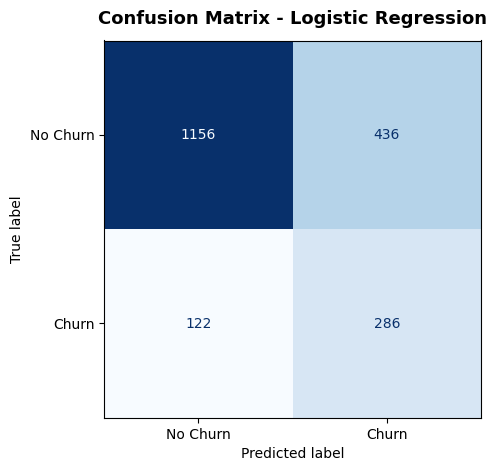

=== Confusion Matrix Summary ===
True Negative  (benar prediksi No Churn) : 1,156
False Positive (salah prediksi Churn)    : 436
False Negative (miss Churn)              : 122
True Positive  (benar prediksi Churn)    : 286


In [26]:
# ngitung confusion matrix
cm = confusion_matrix(y_test, y_pred)

# nampilin confusion matrix
fig, ax = plt.subplots(figsize=(5,5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['No Churn', 'Churn']
)

disp.plot(
    cmap='Blues',
    ax=ax,
    colorbar=False,
    values_format='d'
)

ax.set_title(
    'Confusion Matrix - Logistic Regression',
    fontsize=13,
    fontweight='bold',
    pad=12
)

plt.tight_layout()
plt.show()

# nampilin nilai TN, FP, FN, dan TP
tn, fp, fn, tp = cm.ravel()

print("=== Confusion Matrix Summary ===")
print(f"True Negative  (benar prediksi No Churn) : {tn:,}")
print(f"False Positive (salah prediksi Churn)    : {fp:,}")
print(f"False Negative (miss Churn)              : {fn:,}")
print(f"True Positive  (benar prediksi Churn)    : {tp:,}")

#### 8. ROC curve

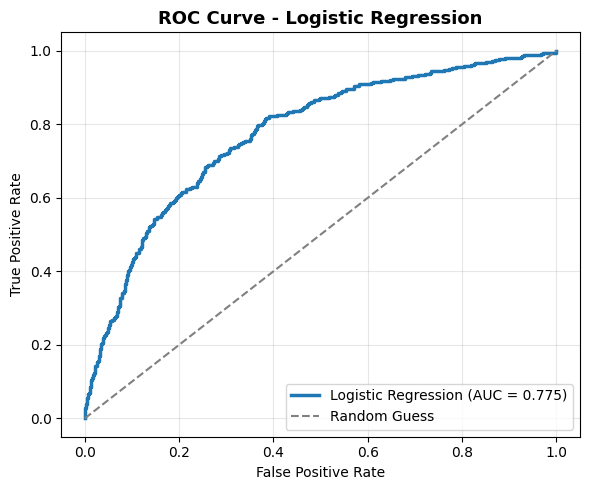

In [27]:
# ngitung False Positive Rate (FPR) & True Positive Rate (TPR)
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# nampilin ROC Curve
plt.figure(figsize=(6,5))

plt.plot(
    fpr,
    tpr,
    linewidth=2.5,
    label=f'Logistic Regression (AUC = {roc_auc:.3f})'
)

# garis acuan model acak
plt.plot(
    [0,1],
    [0,1],
    linestyle='--',
    color='gray',
    linewidth=1.5,
    label='Random Guess'
)

plt.title(
    'ROC Curve - Logistic Regression',
    fontsize=13,
    fontweight='bold'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.legend(loc='lower right')

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### 9. robustness check

In [28]:
# prediksi pada data training
y_train_pred = lr_model.predict(X_train_scaled)
y_train_prob = lr_model.predict_proba(X_train_scaled)[:, 1]

# ngitung performa pada data training
train_f1 = f1_score(y_train, y_train_pred)
train_auc = roc_auc_score(y_train, y_train_prob)

# ngitung performa pada data testing
test_f1 = f1
test_auc = roc_auc

# ngitung selisih performa (performance gap)
f1_gap = abs(train_f1 - test_f1)
auc_gap = abs(train_auc - test_auc)

# nampilin hasil robustness check
print("=== Model Robustness Check ===")

print(f"\nTrain F1-Score : {train_f1:.4f}")
print(f"Test F1-Score  : {test_f1:.4f}")
print(f"F1 Gap         : {f1_gap:.4f}")

print("-----------------------------------------")

print(f"Train ROC-AUC  : {train_auc:.4f}")
print(f"Test ROC-AUC   : {test_auc:.4f}")
print(f"AUC Gap        : {auc_gap:.4f}")

# interpretasi robustness model
if f1_gap < 0.05 and auc_gap < 0.05:
    print("\nConclusion :")
    print("The performance gap between the training and testing data is small,")
    print("indicating that the Logistic Regression model generalizes well")
    print("and does not show significant signs of overfitting.")

else:
    print("\nConclusion :")
    print("The performance gap between the training and testing data is relatively large,")
    print("indicating that the model may suffer from overfitting")
    print("and requires further optimization.")

=== Model Robustness Check ===

Train F1-Score : 0.4953
Test F1-Score  : 0.5062
F1 Gap         : 0.0109
-----------------------------------------
Train ROC-AUC  : 0.7695
Test ROC-AUC   : 0.7748
AUC Gap        : 0.0053

Conclusion :
The performance gap between the training and testing data is small,
indicating that the Logistic Regression model generalizes well
and does not show significant signs of overfitting.


#### 10. logistic regression feature coefficient

=== Logistic Regression Coefficient Analysis ===
                 Feature  Coefficient
0               num__age     0.812310
6   cat__country_Germany     0.812125
8       cat__gender_Male    -0.562224
5     num__active_member    -0.446589
2           num__balance     0.175208
7     cat__country_Spain     0.081737
3   num__products_number    -0.046363
1            num__tenure    -0.041518
4  num__estimated_salary     0.039578


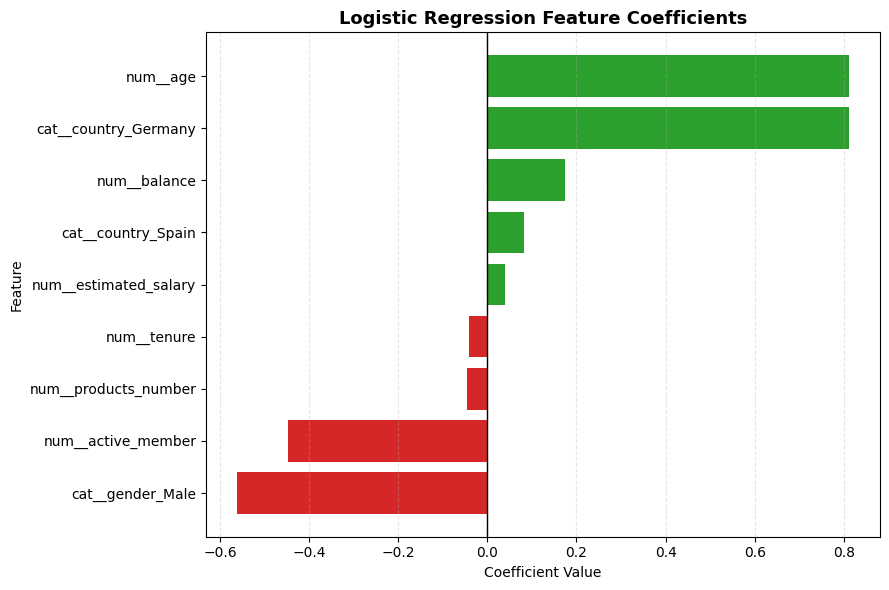

In [29]:
# ngambil nama fitur setelah preprocessing
feature_names = preprocessor.get_feature_names_out()

# buat DataFrame koefisien
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': lr_model.coef_[0]
})

# mengurutkan berdasarkan besar pengaruh
coef_df['Absolute Coefficient'] = coef_df['Coefficient'].abs()

coef_df = coef_df.sort_values(
    by='Absolute Coefficient',
    ascending=False
)

# nampilin tabel koefisien
print("=== Logistic Regression Coefficient Analysis ===")
print(coef_df[['Feature', 'Coefficient']])

# visualisasi koefisien
plot_df = coef_df.sort_values('Coefficient')

plt.figure(figsize=(9,6))

colors = [
    '#2ca02c' if coef > 0 else '#d62728'
    for coef in plot_df['Coefficient']
]

plt.barh(
    plot_df['Feature'],
    plot_df['Coefficient'],
    color=colors
)

plt.axvline(
    x=0,
    color='black',
    linewidth=1
)

plt.title(
    'Logistic Regression Feature Coefficients',
    fontsize=13,
    fontweight='bold'
)

plt.xlabel('Coefficient Value')
plt.ylabel('Feature')

plt.grid(
    axis='x',
    linestyle='--',
    alpha=0.3
)

plt.tight_layout()
plt.show()

### Evaluasi Metode Analitik - Pengembangan Model Klasifikasi Churn

Sebagai pembanding terhadap model *Logistic Regression* (Model 1), notebook ini didedikasikan untuk membangun model kedua menggunakan algoritma **Random Forest Classifier** (Model 2).

Model ensemble berbasis pohon (*tree-based*) ini dipilih karena kemampuannya yang sangat baik dalam menangani hubungan non-linear dan interaksi kompleks antar fitur tanpa memerlukan asumsi linearitas.

Proses evaluasi model diukur menggunakan metrik berikut pada data pengujian (*Test Set*):
1. **F1 Score** — keseimbangan antara Precision dan Recall, terutama untuk imbalanced data
2. **ROC-AUC** — keandalan model membedakan kelas churn vs tidak
3. **Confusion Matrix** — rincian prediksi benar dan salah per kelas
4. **Robustness** — selisih F1 Score dan ROC-AUC antara data training dan testing untuk deteksi overfitting


#### 1. Import Library

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    confusion_matrix, ConfusionMatrixDisplay,
    f1_score
)


#### 2. Load Data & Preprocessing

In [31]:
# 1. Baca dataset final yang sudah bersih
from google.colab import files
uploaded = files.upload()

import io
df_model = pd.read_csv(io.BytesIO(uploaded[next(iter(uploaded))]))

print("Shape:", df_model.shape)
display(df_model.head())

Saving Bank_Customer_Churn_Prediction_FinalCleaned.csv to Bank_Customer_Churn_Prediction_FinalCleaned (1).csv
Shape: (9996, 12)


,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1.0
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0.0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1.0
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0.0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0.0


In [32]:
# 2. One-Hot Encoding untuk variabel kategorikal
df_encoded = pd.get_dummies(df_model, columns=['country', 'gender'], drop_first=True)

# 3. Pisahkan Fitur (X) dan Target (y)
X = df_encoded.drop(columns=['customer_id', 'churn'])
y = df_encoded['churn']

# 4. Train-Test Split — stratify=y agar proporsi churn seimbang di train & test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size : {X_train.shape[0]:,} baris")
print(f"Test size  : {X_test.shape[0]:,} baris")
print(f"Churn ratio (train): {y_train.mean():.2%}")

Train size : 7,996 baris
Test size  : 2,000 baris
Churn ratio (train): 20.37%


#### 3. Training Model Random Forest

> **Catatan parameter:**
> - `n_estimators=200` — jumlah pohon; lebih banyak = lebih stabil (default 100 terlalu sedikit)
> - `max_depth=10` — batasi kedalaman pohon agar tidak overfit
> - `min_samples_leaf=5` — minimum sampel di tiap leaf; cegah pohon hafal data training
> - `class_weight='balanced'` — beri bobot lebih pada kelas minoritas (Churn) untuk tangani imbalance


In [33]:
rf_model = RandomForestClassifier(
    n_estimators=200,        # tambahan: default 100 kurang stabil untuk 10K data
    max_depth=10,
    min_samples_leaf=5,      # tambahan: cegah overfitting di level leaf
    class_weight='balanced',
    random_state=42,
    n_jobs=-1                # pakai semua CPU core
)

rf_model.fit(X_train, y_train)
print("Model trained ✓")

Model trained ✓


#### 4. Prediksi & Cek Robustness

In [41]:
y_pred       = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]

# --- F1-based Robustness ---
train_f1 = f1_score(y_train, rf_model.predict(X_train))
test_f1  = f1_score(y_test, y_pred)
gap_f1   = train_f1 - test_f1

# --- ROC-AUC-based Robustness ---
train_roc = roc_auc_score(y_train, rf_model.predict_proba(X_train)[:, 1])
test_roc  = roc_auc_score(y_test, y_pred_proba)
gap_roc   = train_roc - test_roc

print("=== CEK ROBUSTNESS ===")
print()
print("[ F1 Score ]")
print(f"  Train F1 Score : {train_f1:.4f} ({train_f1*100:.2f}%)")
print(f"  Test F1 Score  : {test_f1:.4f} ({test_f1*100:.2f}%)")
print(f"  Gap            : {gap_f1:.4f}")
if gap_f1 > 0.10:
    print("  → Gap > 10% — model kurang robust pada F1 (kemungkinan OVERFIT).")
else:
    print("  → Gap < 10% — model robust pada F1.")

print()
print("[ ROC-AUC ]")
print(f"  Train ROC-AUC  : {train_roc:.4f}")
print(f"  Test ROC-AUC   : {test_roc:.4f}")
print(f"  Gap            : {gap_roc:.4f}")
if gap_roc > 0.05:
    print("  → Gap > 5% — model kurang robust pada ROC-AUC (kemungkinan OVERFIT).")
else:
    print("  → Gap < 5% — model robust pada ROC-AUC.")


=== CEK ROBUSTNESS ===

[ F1 Score ]
  Train F1 Score : 0.7419 (74.19%)
  Test F1 Score  : 0.6240 (62.40%)
  Gap            : 0.1179
  → Gap > 10% — model kurang robust pada F1 (kemungkinan OVERFIT).

[ ROC-AUC ]
  Train ROC-AUC  : 0.9465
  Test ROC-AUC   : 0.8621
  Gap            : 0.0844
  → Gap > 5% — model kurang robust pada ROC-AUC (kemungkinan OVERFIT).


#### 5. Hyperparameter Tuning — RandomizedSearchCV

> **Mengapa RandomizedSearchCV?**
> Dibanding GridSearchCV yang mencoba *semua* kombinasi parameter, RandomizedSearchCV hanya mengambil sampel acak sebanyak `n_iter` kombinasi dari ruang parameter yang ditentukan. Hasilnya tetap optimal karena ruang pencarian di-*cover* secara probabilistik, namun waktu komputasi jauh lebih singkat — sangat cocok untuk environment Colab.


In [42]:
param_dist = {
    'n_estimators'    : [100, 200, 300, 500],
    'max_depth'       : [5, 8, 10, 15, None],
    'min_samples_leaf': [2, 5, 10, 20],
    'max_features'    : ['sqrt', 'log2', 0.5],
    'class_weight'    : ['balanced', 'balanced_subsample']
}

base_rf = RandomForestClassifier(random_state=42, n_jobs=-1)

# multi-metric scoring: optimasi F1, tapi rekam juga ROC-AUC
random_search = RandomizedSearchCV(
    estimator           = base_rf,
    param_distributions = param_dist,
    n_iter              = 50,
    scoring             = {'f1': 'f1', 'roc_auc': 'roc_auc'},
    refit               = 'f1',       # model terbaik dipilih berdasarkan F1
    cv                  = 5,
    random_state        = 42,
    n_jobs              = -1,
    verbose             = 1
)

random_search.fit(X_train, y_train)

best_cv_f1  = random_search.cv_results_['mean_test_f1'][random_search.best_index_]
best_cv_auc = random_search.cv_results_['mean_test_roc_auc'][random_search.best_index_]

print("=== HASIL TUNING ===")
print(f"Best F1 Score (CV)  : {best_cv_f1:.4f}")
print(f"Best ROC-AUC (CV)   : {best_cv_auc:.4f}")
print(f"Best Parameters     :")
for k, v in random_search.best_params_.items():
    print(f"  {k}: {v}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
=== HASIL TUNING ===
Best F1 Score (CV)  : 0.6292
Best ROC-AUC (CV)   : 0.8628
Best Parameters     :
  n_estimators: 500
  min_samples_leaf: 5
  max_features: sqrt
  max_depth: 15
  class_weight: balanced_subsample


#### 6. Cross-Validation — StratifiedKFold

> **StratifiedKFold** memastikan setiap fold memiliki proporsi kelas churn yang sama dengan distribusi asli data, sehingga evaluasi tidak bias meskipun data tidak seimbang (*imbalanced*).


In [43]:
best_rf = random_search.best_estimator_

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_f1  = cross_val_score(best_rf, X_train, y_train, cv=skf, scoring='f1',      n_jobs=-1)
cv_roc = cross_val_score(best_rf, X_train, y_train, cv=skf, scoring='roc_auc', n_jobs=-1)

print("=== HASIL CROSS-VALIDATION (5-Fold StratifiedKFold) ===")
print()
print("[ F1 Score per Fold ]")
for i, s in enumerate(cv_f1, 1):
    print(f"  Fold {i}: {s:.4f}")
print(f"  Mean  : {cv_f1.mean():.4f} ± {cv_f1.std():.4f}")

print()
print("[ ROC-AUC per Fold ]")
for i, s in enumerate(cv_roc, 1):
    print(f"  Fold {i}: {s:.4f}")
print(f"  Mean  : {cv_roc.mean():.4f} ± {cv_roc.std():.4f}")

=== HASIL CROSS-VALIDATION (5-Fold StratifiedKFold) ===

[ F1 Score per Fold ]
  Fold 1: 0.5997
  Fold 2: 0.6399
  Fold 3: 0.6159
  Fold 4: 0.6340
  Fold 5: 0.6152
  Mean  : 0.6209 ± 0.0144

[ ROC-AUC per Fold ]
  Fold 1: 0.8541
  Fold 2: 0.8703
  Fold 3: 0.8673
  Fold 4: 0.8601
  Fold 5: 0.8558
  Mean  : 0.8615 ± 0.0063


#### 7. Evaluasi Metrik

In [44]:
# prediksi probabilitas dari model terbaik
y_pred_proba = best_rf.predict_proba(X_test)[:, 1]

# --- cari threshold optimal dari ROC curve ---
fpr_arr, tpr_arr, thresholds_arr = roc_curve(y_test, y_pred_proba)
optimal_idx       = np.argmax(tpr_arr - fpr_arr)
optimal_threshold = thresholds_arr[optimal_idx]

# prediksi final pakai threshold optimal (bukan default 0.5)
y_pred  = (y_pred_proba >= optimal_threshold).astype(int)

f1      = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("=== HASIL EVALUASI MODEL KEDUA (RANDOM FOREST — SETELAH TUNING) ===")
print(f"Threshold yang digunakan : {optimal_threshold:.4f} (optimal, dari ROC curve)")
print(f"1. F1 Score              : {f1:.4f} ({f1*100:.2f}%)")
print(f"2. ROC-AUC Score         : {roc_auc:.4f}")

=== HASIL EVALUASI MODEL KEDUA (RANDOM FOREST — SETELAH TUNING) ===
Threshold yang digunakan : 0.4230 (optimal, dari ROC curve)
1. F1 Score              : 0.6364 (63.64%)
2. ROC-AUC Score         : 0.8602


#### 8. Visualisasi — Confusion Matrix

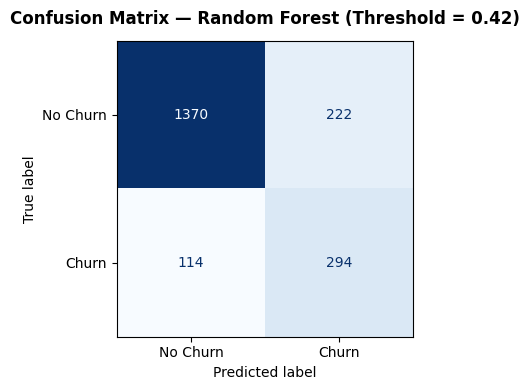

True Negative  (benar prediksi No Churn) : 1,370
False Positive (salah prediksi Churn)    : 222
False Negative (miss Churn)              : 114
True Positive  (benar prediksi Churn)   : 294


In [45]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
disp.plot(cmap='Blues', ax=ax, colorbar=False)
ax.set_title(f'Confusion Matrix — Random Forest (Threshold = {optimal_threshold:.2f})',
             fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negative  (benar prediksi No Churn) : {tn:,}")
print(f"False Positive (salah prediksi Churn)    : {fp:,}")
print(f"False Negative (miss Churn)              : {fn:,}")
print(f"True Positive  (benar prediksi Churn)   : {tp:,}")


#### 9. Visualisasi — ROC Curve

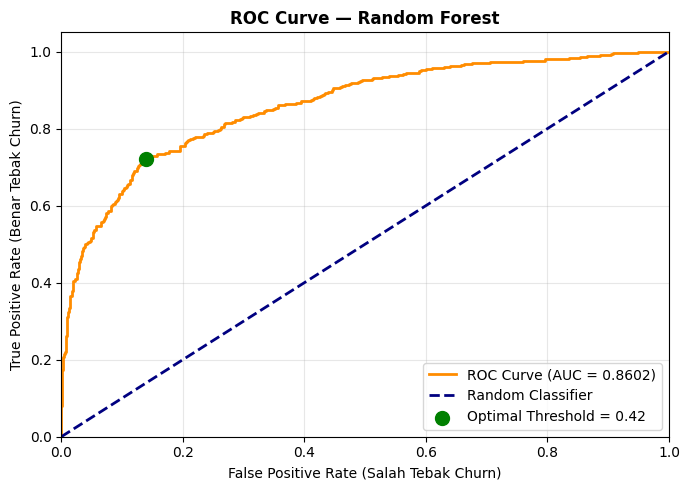

In [39]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Cari optimal threshold (titik paling dekat ke pojok kiri atas)
optimal_idx       = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--',
         label='Random Classifier')
plt.scatter(fpr[optimal_idx], tpr[optimal_idx],
            color='green', s=100, zorder=5,
            label=f'Optimal Threshold = {optimal_threshold:.2f}')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Salah Tebak Churn)')
plt.ylabel('True Positive Rate (Benar Tebak Churn)')
plt.title('ROC Curve — Random Forest', fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 2B

### 10. Feature Importance

> Menjadi salah satu keunggulan Random Forest dibanding Logistic Regression, kita bisa langsung tahu fitur mana yang paling berpengaruh terhadap prediksi churn.


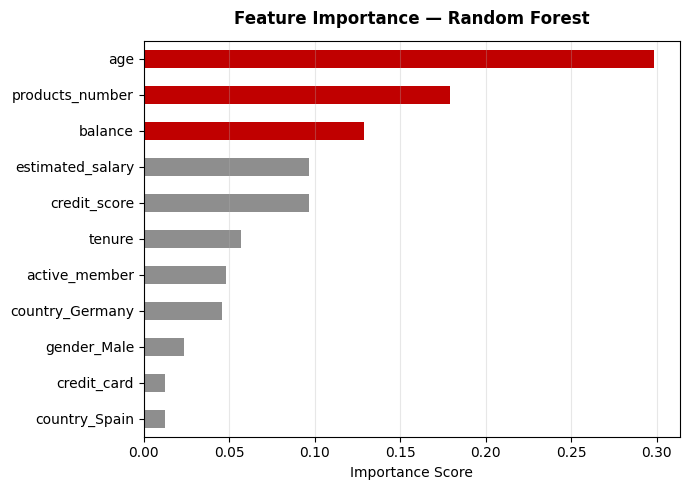


=== Feature Importance (Descending) ===
age                 0.2987
products_number     0.1794
balance             0.1291
estimated_salary    0.0969
credit_score        0.0965
tenure              0.0567
active_member       0.0481
country_Germany     0.0459
gender_Male         0.0238
credit_card         0.0126
country_Spain       0.0124


In [40]:
feat_imp = pd.Series(best_rf.feature_importances_, index=X.columns) \
             .sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(7, 5))
colors = ['#C00000' if i >= len(feat_imp)-3 else '#8E8E8E'
          for i in range(len(feat_imp))]
feat_imp.plot(kind='barh', ax=ax, color=colors, edgecolor='none')
ax.set_title('Feature Importance — Random Forest', fontweight='bold', pad=12)
ax.set_xlabel('Importance Score')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n=== Feature Importance (Descending) ===")
print(feat_imp.sort_values(ascending=False).round(4).to_string())
